<a href="https://colab.research.google.com/github/denverkim/DM_FALL2026/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load the iris dataset and create a data frame named df (including target and feature names). 붓꽃데이터를 열어 타겟과 속성이름을 포함한 df 만들기

from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# X and y split. 독립, 종속변수 분리
y = df['species']
x = df.drop('species', axis=1)

In [ ]:
# Splitting Dataset (test size=.2). 데이터셋 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=1)

In [ ]:
x_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
91,6.1,3.0,4.6,1.4
135,7.7,3.0,6.1,2.3
69,5.6,2.5,3.9,1.1
128,6.4,2.8,5.6,2.1
114,5.8,2.8,5.1,2.4
...,...,...,...,...
133,6.3,2.8,5.1,1.5
137,6.4,3.1,5.5,1.8
72,6.3,2.5,4.9,1.5
140,6.7,3.1,5.6,2.4


In [ ]:
x_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
14,5.8,4.0,1.2,0.2
98,5.1,2.5,3.0,1.1
75,6.6,3.0,4.4,1.4
16,5.4,3.9,1.3,0.4
131,7.9,3.8,6.4,2.0
56,6.3,3.3,4.7,1.6
141,6.9,3.1,5.1,2.3
44,5.1,3.8,1.9,0.4
29,4.7,3.2,1.6,0.2
120,6.9,3.2,5.7,2.3


In [ ]:
y_train

,species
91,1
135,2
69,1
128,2
114,2
...,...
133,2
137,2
72,1
140,2


In [ ]:
y_test

,species
14,0
98,1
75,1
16,0
131,2
56,1
141,2
44,0
29,0
120,2


In [ ]:
# Decision Tree 의사결정트리
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3)

dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
# Model evaluation (accuracy score) 모델평가
print('모델 정확도: ', dt.score(x_test, y_test))
from sklearn.metrics import accuracy_score

y_pred = dt.predict(x_test)
accuracy_score(y_test, y_pred)

모델 정확도:  0.9666666666666667


0.9666666666666667

In [ ]:
# 5 fold cross validation (5 fold) 교차검증
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(dt, x_test, y_test, cv=5)
print('교차검증 평균: ', dt_cv.mean(), '\n표준편차:', dt_cv.std())

교차검증 평균:  0.9333333333333333 
표준편차: 0.08164965809277258


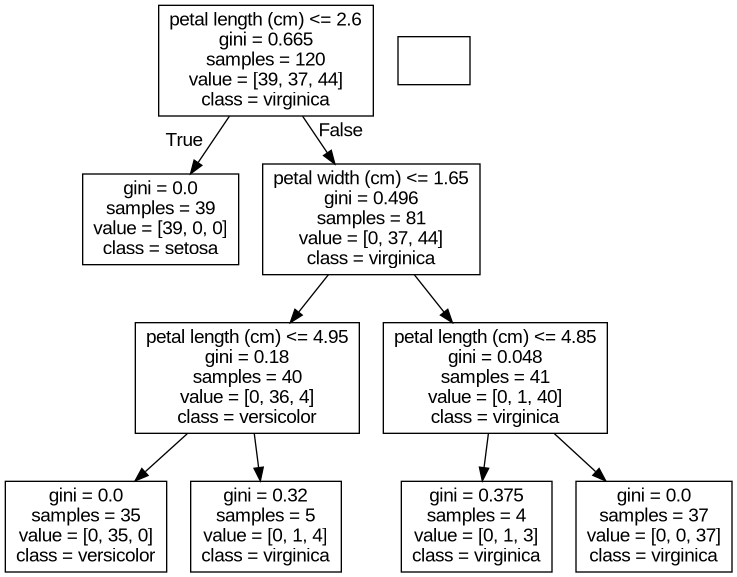

In [ ]:
# Decision tree visualization (max depth=3) 의사결정트리 시각화
from IPython.display import Image
from sklearn import tree
import pydotplus
dot_data = tree.export_graphviz(dt, out_file=None,feature_names=iris.feature_names,                                class_names=iris.target_names)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [ ]:
dt=DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(x_train, y_train)
data_feature_names = ['Sepal Lenth', 'Sepal Width', 'Petal Length', 'Petal Width']
dot_data = tree.export_graphviz(dt, feature_names=data_feature_names, out_file=None, filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

TypeError: sequence item 1: expected str instance, ParseResults found

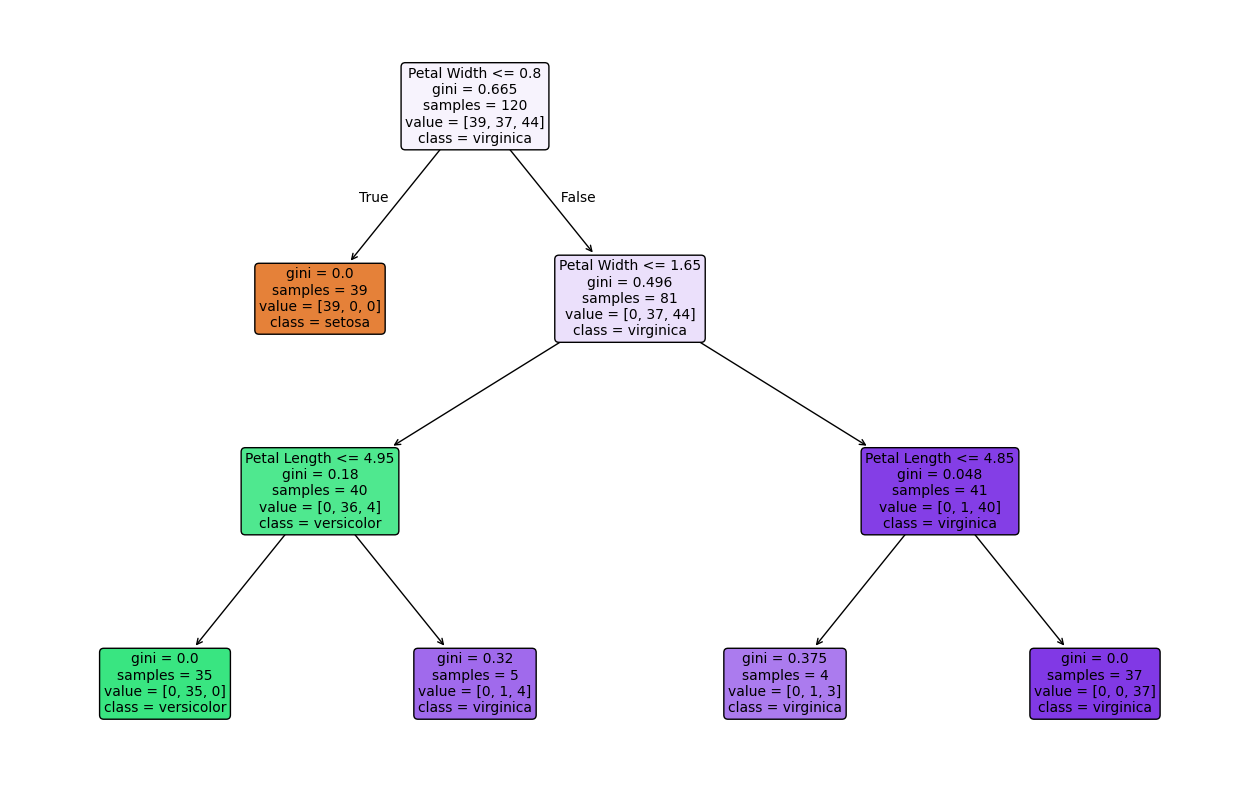

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

plot_tree(
    dt,
    feature_names=data_feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [ ]:
# Random Forest 랜덤포레스트
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
# Model evaluation (accuracy score) 모델평가
rf.score(x_test, y_test)

0.9666666666666667

In [ ]:
# 5 fold cross validation (5 fold) 5배 교차검증
rf_cv = cross_val_score(rf, x_train, y_train, cv=5)
print('교차검증 평균: ', rf_cv.mean(), '\n교차검증 표준편차:', rf_cv.std())

교차검증 평균:  0.9416666666666668 
교차검증 표준편차: 0.05651941652604389
